In [6]:
import pandas as pd
import numpy as np
df = pd.read_csv("iris_dirty.csv")

print(df.columns.tolist())
# print(df.dtypes)
print('\nMissing values:\n', df.isnull().sum())
print('\nRow count:', len(df))
print('\nTarget distribution:\n', df['label'].value_counts(normalize=True))

# Check and drop duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print(f'Original rows: {before}')
print(f'Duplicate rows removed: {before - after}')

# Drop rows with any missing values
missing_before = df.isna().sum().sum()
df = df.dropna()
missing_after = df.isna().sum().sum()

print(f'Missing values removed: {missing_before - missing_after}')
print(f'Rows after dropping missing values: {df.shape[0]}')
print(f'Rows after all cleaning: {df.shape[0]}')

# print(f'Unique customer_id count: {df["customer_id"].nunique()}')

['f1', 'f2', 'f3', 'f4', 'label']

Missing values:
 f1       1
f2       2
f3       2
f4       1
label    0
dtype: int64

Row count: 154

Target distribution:
 label
Iris-setosa        0.337662
Iris-versicolor    0.331169
Iris-virginica     0.331169
Name: proportion, dtype: float64
Original rows: 154
Duplicate rows removed: 5
Missing values removed: 6
Rows after dropping missing values: 143
Rows after all cleaning: 143


In [7]:
df.describe()

,f1,f2,f3,f4
count,143.000000,143.000000,143.000000,143.000000
mean,5.850350,3.053147,3.758042,1.197902
std,0.823328,0.437954,1.750147,0.757541
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


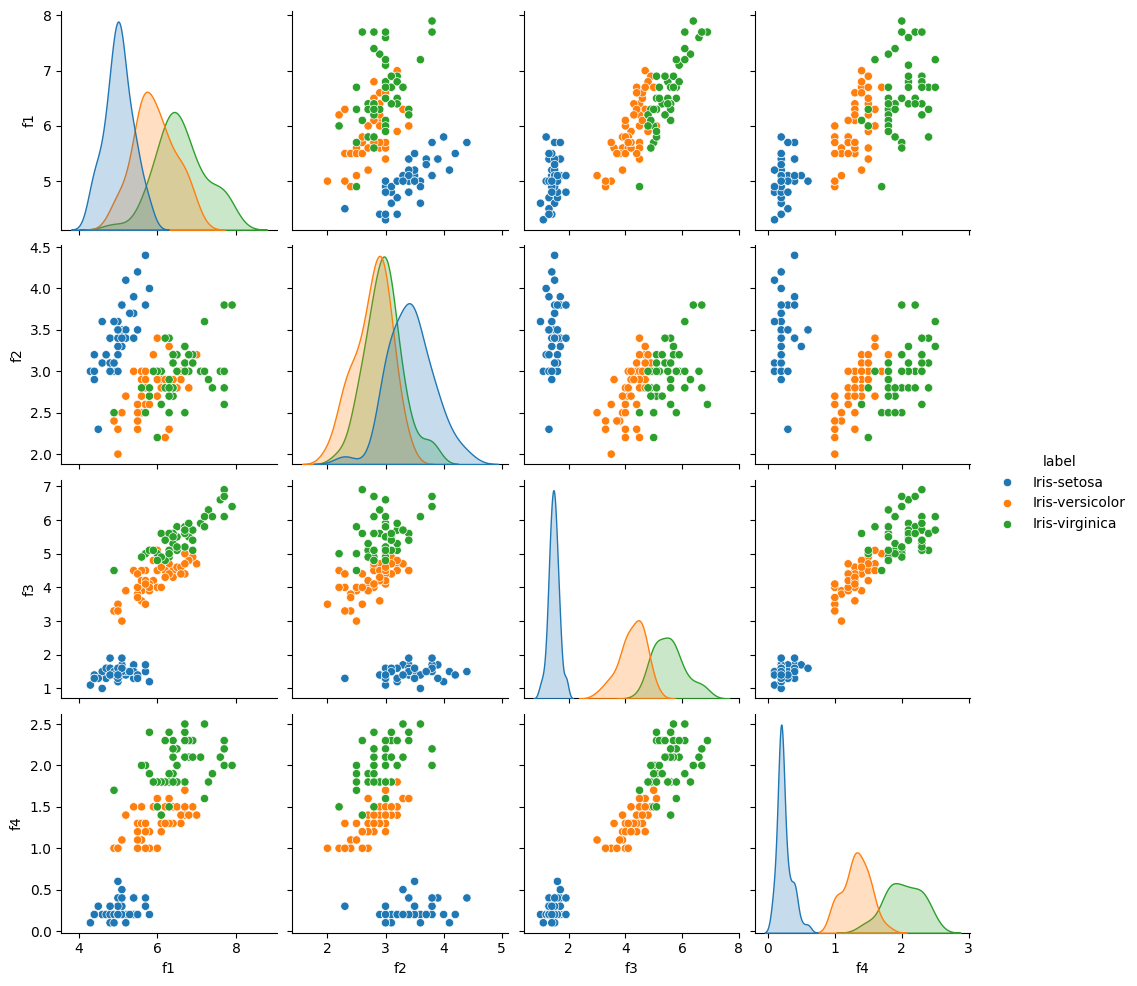

In [8]:
import seaborn as sns
sns.pairplot(df, hue="label")

In [5]:
import pandas as pd
import numpy as np
# Check and clean missing values
df = pd.read_csv("iris_dirty.csv")
print('Before cleaning:')
print("missing values\n", df.isnull().sum())
print(df.shape)
# Fill missing numeric values with median, categorical with mode
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print('\nAfter cleaning:')
print("missing values\n",df.isnull().sum())
print(df.shape)

# Normalize categorical values if needed
if 'AdType' in df.columns:
    df['AdType'] = df['AdType'].astype(str).str.strip().str.title()

print('\nClean dataset preview:')
df.head()

Before cleaning:
missing values
 f1       1
f2       2
f3       2
f4       1
label    0
dtype: int64
(154, 5)

After cleaning:
missing values
 f1       0
f2       0
f3       0
f4       0
label    0
dtype: int64
(154, 5)

Clean dataset preview:


,f1,f2,f3,f4,label
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
def defineTargetVar(row):
    if row['label'] == 'Iris-setosa':
        val = 0
    elif row['label'] == 'Iris-versicolor':
        val = 1
    else: #if row['label'] == 'Iris-virginica':
        val = 2
    # else:
    #     val = 3
    return val

def make_balanced_df(df_obj, target_col='label'):
    class_counts = df_obj[target_col].value_counts()
    print(class_counts)
    minority_class = class_counts.idxmin()
    majority_class = class_counts.idxmax()

    df_minority = df_obj[df_obj[target_col] == minority_class]
    df_majority = df_obj[df_obj[target_col] == majority_class]

    df_majority_downsampled = df_majority.sample(
        n=len(df_minority),
        random_state=42
    )

    df_balanced = pd.concat(
        [df_minority, df_majority_downsampled]
    ).sample(
        frac=1,
        random_state=42
    ).reset_index(drop=True)


    print(f'Balanced dataset size: {df_balanced.shape}')
    print(f'Balanced target distribution:\n{df_balanced[target_col].value_counts()}')
    return df_balanced


# Balance the dataset first

df_bal = make_balanced_df(df, target_col='label')
df_bal.shape

label
Iris-setosa        52
Iris-versicolor    51
Iris-virginica     51
Name: count, dtype: int64
Balanced dataset size: (102, 5)
Balanced target distribution:
label
Iris-versicolor    51
Iris-setosa        51
Name: count, dtype: int64


(102, 5)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from xgboost import XGBClassifier
import warnings
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
X = df[['f1', 'f2', 'f3', 'f4']]
df["label_int"] = df.apply(defineTargetVar, axis=1)
y = df.label_int
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [ ]:
# X = pd.get_dummies(X, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Target distribution in train:', y_train.value_counts(normalize=True).to_dict())

NameError: name 'pd' is not defined

In [4]:
# Logistic Regression
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train, y_train)
# weights = np.where(train_y == 0, 2, train_y)
# weights = np.where(weights == 1, 2, weights)
# weights = np.where(weights == 2, 6, weights)

# lr.fit(train_x, train_y, weights)


lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

print('Logistic Regression Metrics')
print('Accuracy:', round(accuracy_score(y_test, lr_pred), 4))
print('Precision:', round(precision_score(y_test, lr_pred), 4))
print('Recall:', round(recall_score(y_test, lr_pred), 4))
print('F1:', round(f1_score(y_test, lr_pred), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, lr_prob), 4))
print(classification_report(y_test, lr_pred))

NameError: name 'LogisticRegression' is not defined

In [7]:
clf = DecisionTreeClassifier(random_state=0)
scores = cross_val_score(clf, one_hot_data, dfObj['label'], cv=5)
print("cross validation scores", scores)
colNames = list(one_hot_data.columns)
imp = decTree.feature_importances_
print(decTree.feature_importances_)

ind = np.argsort(-decTree.feature_importances_)[:TopKFeatures]
print('Top', TopKFeatures, 'important features')
for i in range(TopKFeatures):
    print(colNames[ind[i]], ' ,  ', decTree.feature_importances_[ind[i]])

NameError: name 'DecisionTreeClassifier' is not defined

In [10]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    'F1': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

print(results.round(4).to_string(index=False))

NameError: name 'pd' is not defined

In [11]:
cm = confusion_matrix(y_test, lr_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=['Not Clicked', 'Clicked'], yticklabels=['Not Clicked', 'Clicked'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


NameError: name 'confusion_matrix' is not defined

In [12]:
# misclassified
# XGBoost on BERT embeddings
# Keep tweet IDs and original text so we can inspect bad predictions later.
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

X = X_emb
ids = df['tweet_id'].astype(str).to_numpy()
texts = df['tweet_text'].astype(str).to_numpy()

X_train, X_test, y_train, y_test, ids_train, ids_test, texts_train, texts_test = train_test_split(
    X, y, ids, texts, test_size=0.2, random_state=42, stratify=y
)

xgb = XGBClassifier(
    objective='binary:logistic',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=1,
    verbosity=0
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print('XGBoost classification report:')
print(classification_report(y_test, y_pred, target_names=['sad', 'happy']))

print('\nXGBoost confusion matrix:')
print(confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['sad', 'happy'],
    cmap='Blues',
    normalize='true'
)
plt.show()

# Error analysis: look at the tweets that were misclassified.
results_df = pd.DataFrame({
    'tweet_id': ids_test,
    'text': texts_test,
    'actual': y_test,
    'predicted': y_pred,
    'correct': y_pred == y_test,
})

misclassified = results_df[results_df['correct'] == False].copy()
misclassified['actual_label'] = misclassified['actual'].map({0: 'sad', 1: 'happy'})
misclassified['predicted_label'] = misclassified['predicted'].map({0: 'sad', 1: 'happy'})

print('\nMisclassified tweets:')
print(misclassified[['tweet_id', 'actual_label', 'predicted_label', 'text']].head(20).to_string(index=False))


NameError: name 'X_emb' is not defined